# Plot Figure 1E - Main Panel (wt)

This notebook generates the main figure showing regrowth probability as a function of spatial position.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

Data loaded successfully!
Colonies: 195 rows
Regrowth stats: 20 rows

Regrowth columns: ['axis', 'bin_left', 'mean_regrowth_fraction', 'std_regrowth_fraction', 'n_replicates']

Figure saved: 1E_wt.pdf


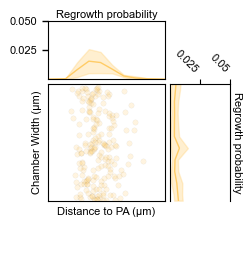

In [2]:
# ----------------------------------------------------------------------
# Data -----------------------------------------------------------------
try:
    colonies_df = pd.read_csv(
        '1_first_colonies_wt_merged.csv'
    )
    # Use the FINAL merged file with mean across replicates
    regrowth_df = pd.read_csv(
        '1_regrowth_fractions_wt_merged.csv'
    )
    print("Data loaded successfully!")
    print(f"Colonies: {len(colonies_df)} rows")
    print(f"Regrowth stats: {len(regrowth_df)} rows")
    print("\nRegrowth columns:", regrowth_df.columns.tolist())
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    raise

# ----------------------------------------------------------------------
# Constants -------------------------------------------------------------
num_bins      = 10
pnas_fontsize = 8
fig_width, fig_height = 3, 2.5   # inches
color_wt = '#ffcc66'
replicate_markers = {'rep1': 'o', 'rep2': 'o', 'rep3': 'o'}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Determine data range for plotting
x_max = max(colonies_df['x_um'].max(), colonies_df['y_um'].max())
x_max = np.ceil(x_max / 10) * 10  # Round up to nearest 10

# Calculate bin width from data
bin_width = x_max / num_bins

# ----------------------------------------------------------------------
# Figure & GridSpec -----------------------------------------------------
fig = plt.figure(figsize=(fig_width, fig_height))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1, 0.4],
    height_ratios=[2, 1]
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[1, 1])

# ----------------------------------------------------------------------
# Plotting --------------------------------------------------------------
# --- Plot 1: Scatter (rotated) ---
for rep, marker in replicate_markers.items():
    df_rep = colonies_df[colonies_df['replicate'] == rep]
    ax1.scatter(df_rep['y_um'], df_rep['x_um'],   # swapped to rotate
                marker=marker, label=rep,
                color=color_wt, s=15, alpha=0.2,
                edgecolors='k', linewidths=0.1)

ax1.set_aspect('equal', adjustable='box', anchor='W')
ax1.set_xlim(0, x_max); ax1.set_ylim(0, x_max)
ax1.set_xlabel('Distance to PA (µm)', fontsize=pnas_fontsize)
ax1.set_ylabel('Chamber Width (µm)', fontsize=pnas_fontsize)
ax1.grid(False)
ax1.set_title(r'$ \it{P.\ aeruginosa}\ \mathrm{wt}$', fontsize=pnas_fontsize)

# Flip horizontally (mirror along x-axis)
ax1.invert_yaxis()

# Helper to linearly extend first/last bin-center values to the edges
def extend_to_edges(centers, values, left_edge=0.0, right_edge=None):
    if right_edge is None:
        right_edge = x_max
    centers = np.asarray(centers)
    values  = np.asarray(values)
    if len(centers) < 2:
        x = np.array([left_edge, centers[0], right_edge])
        y = np.array([values[0], values[0], values[0]])
        return x, y
    # Left extrapolation
    m_left   = (values[1] - values[0]) / (centers[1] - centers[0])
    left_val = values[0] - m_left * (centers[0] - left_edge)
    # Right extrapolation
    m_right   = (values[-1] - values[-2]) / (centers[-1] - centers[-2])
    right_val = values[-1] + m_right * (right_edge - centers[-1])
    x = np.concatenate(([left_edge], centers, [right_edge]))
    y = np.concatenate(([left_val],  values,  [right_val]))
    return x, y

# --- Plot 2: X-axis regrowth (horizontal) ---
# Columns: axis, bin_left, mean_regrowth_fraction, std_regrowth_fraction, n_replicates
reg_x = regrowth_df[regrowth_df['axis'] == 'x'].copy()
reg_x = reg_x.sort_values('bin_left')

centers_x = reg_x['bin_left'].values + bin_width / 2.0
means_x   = reg_x['mean_regrowth_fraction'].values
stds_x    = reg_x['std_regrowth_fraction'].values

# Extend to edges
y_line_x, mean_line_x = extend_to_edges(centers_x, means_x, left_edge=0.0, right_edge=x_max)
_, std_line_x = extend_to_edges(centers_x, stds_x, left_edge=0.0, right_edge=x_max)
std_line_x[0]  = stds_x[0]
std_line_x[-1] = stds_x[-1]

ax2.plot(mean_line_x, y_line_x, color=color_wt, linewidth=1)
ax2.fill_betweenx(y_line_x, mean_line_x - std_line_x, mean_line_x + std_line_x,
                  color=color_wt, alpha=0.3)

# Determine x-axis limits for regrowth probability
max_regrowth = max(means_x.max() + stds_x.max(), 0.1)
max_regrowth = np.ceil(max_regrowth * 10) / 10  # Round up to nearest 0.1

ax2.set_ylabel('Regrowth probability', fontsize=pnas_fontsize, rotation=-90, labelpad=-45)
ax2.set_xlim(0, 0.05); ax2.set_ylim(0, x_max)
ax2.set_yticks([])
ax2.set_xticks([0.025, 0.05])
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()
ax2.tick_params(axis='x', labelsize=pnas_fontsize)
ax2.set_xticklabels(ax2.get_xticks(), rotation=-45, ha='right')
ax2.grid(False)

# Spine
ax2.spines['top'].set_visible(True)
ax2.spines['bottom'].set_visible(False)

# --- Plot 3: Y-axis regrowth (vertical) ---
reg_y = regrowth_df[regrowth_df['axis'] == 'y'].copy()
reg_y = reg_y.sort_values('bin_left')

centers_y = reg_y['bin_left'].values + bin_width / 2.0
means_y   = reg_y['mean_regrowth_fraction'].values
stds_y    = reg_y['std_regrowth_fraction'].values

x_line_y, mean_line_y = extend_to_edges(centers_y, means_y, left_edge=0.0, right_edge=x_max)
_, std_line_y = extend_to_edges(centers_y, stds_y, left_edge=0.0, right_edge=x_max)
std_line_y[0]  = stds_y[0]
std_line_y[-1] = stds_y[-1]

ax3.plot(x_line_y, mean_line_y, color=color_wt, linewidth=1)
ax3.fill_between(x_line_y, mean_line_y - std_line_y, mean_line_y + std_line_y,
                 color=color_wt, alpha=0.3)

ax3.set_xlabel('Regrowth probability', fontsize=pnas_fontsize, labelpad=-50)
ax3.set_xlim(0, x_max); ax3.set_ylim(0, 0.05)
ax3.set_xticks([])
ax3.set_yticks([0.025, 0.05])
ax3.tick_params(axis='y', labelsize=pnas_fontsize, direction='out', length=4, width=1)
ax3.grid(False)

# --- Plot 4: Legend ---
ax4.axis('off')

# ----------------------------------------------------------------------
# Manual Alignment ------------------------------------------------------
fig.canvas.draw()

w_gap_in = 0.05
h_gap_in = 0.05
w_gap_fig = w_gap_in / fig_width
h_gap_fig = h_gap_in / fig_height

bbox1_data = ax1.get_position()
bbox2_full = ax2.get_position()
bbox3_full = ax3.get_position()
bbox4_full = ax4.get_position()

# Align ax3 ABOVE ax1
ax3.set_position([
    bbox1_data.x0,
    bbox1_data.y1 + h_gap_fig,
    bbox1_data.width,
    bbox3_full.height
])

# Align ax2
ax2.set_position([
    bbox1_data.x0 + bbox1_data.width + w_gap_fig,
    bbox1_data.y0,
    bbox2_full.width,
    bbox1_data.height
])

# Align ax4
bbox2_new = ax2.get_position()
ax4.set_position([
    bbox2_new.x0,
    bbox1_data.y0 - bbox4_full.height - h_gap_fig,
    bbox2_new.width,
    bbox4_full.height
])

# ----------------------------------------------------------------------
# Cosmetics -------------------------------------------------------------
for ax in (ax1, ax2, ax3):
    ax.tick_params(axis='both', labelsize=pnas_fontsize)

ax3.tick_params(axis='y', which='both', left=True, labelleft=True)

# Save figure
output_path = '1E_wt.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"\nFigure saved: {output_path}")

plt.show()